11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset shape: (60000, 28, 28, 1)

--- Generator Summary ---


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 247,440 (966.56 KB)

 Trainable params: 247,440 (966.56 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,985 (914.00 KB)

 Trainable params: 233,985 (914.00 KB)

 Non-trainable params: 0 (0.00 B)


Starting GAN Training...
Epoch: 0     | D Loss: 1.2708125 | G Loss: 0.8690177
Epoch: 1000  | D Loss: 0.1620177 | G Loss: 5.8238816
Epoch: 2000  | D Loss: 0.1802807 | G Loss: 5.3040290
Epoch: 3000  | D Loss: 0.2138487 | G Loss: 4.8193674
Epoch: 4000  | D Loss: 0.2300803 | G Loss: 4.4599237
Epoch: 5000  | D Loss: 0.2494494 | G Loss: 4.1511364
Epoch: 6000  | D Loss: 0.2713757 | G Loss: 3.8755364
Epoch: 7000  | D Loss: 0.2909978 | G Loss: 3.6310740
Epoch: 8000  | D Loss: 0.3046949 | G Loss: 3.4525075
Epoch: 9000  | D Loss: 0.3160744 | G Loss: 3.3088827


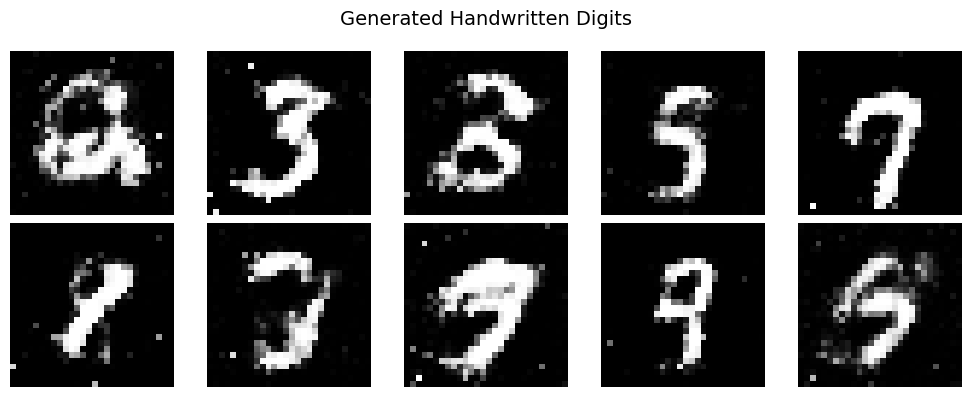

In [ ]:
#kalyani_23070621036
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# ------------------------------------------------------------------------------
# 1. Load and Preprocess Dataset
# ------------------------------------------------------------------------------
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to range [-1, 1] for tanh activation
x_train = (x_train.astype('float32') / 127.5) - 1.0
x_train = np.expand_dims(x_train, axis=-1)

print(f"Dataset shape: {x_train.shape}")

# ------------------------------------------------------------------------------
# 2. Build Generator Network
# ------------------------------------------------------------------------------
generator = Sequential([
    layers.Input(shape=(100,)),
    layers.Dense(128),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Dense(256),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Dense(784, activation='tanh'),
    layers.Reshape((28, 28, 1))
], name="Generator")

print("\n--- Generator Summary ---")
generator.summary()

# ------------------------------------------------------------------------------
# 3. Build Discriminator Network
# ------------------------------------------------------------------------------
discriminator = Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(256),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Dense(128),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Dense(1, activation='sigmoid')
], name="Discriminator")

print("\n--- Discriminator Summary ---")
discriminator.summary()

# Compile the standalone discriminator
discriminator.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ------------------------------------------------------------------------------
# 4. Build and Compile Combined GAN (Generator + Discriminator)
# ------------------------------------------------------------------------------
discriminator.trainable = False

gan = Sequential([generator, discriminator], name="GAN")
gan.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# ------------------------------------------------------------------------------
# 5. Training Loop
# ------------------------------------------------------------------------------
epochs = 10000
batch_size = 128
half_batch = batch_size // 2

print("\nStarting GAN Training...")
for epoch in range(epochs):
    # --- Train Discriminator ---
    # Sample real images
    idx = np.random.randint(0, x_train.shape[0], half_batch)
    real = x_train[idx]

    # Generate fake images from random noise
    noise = np.random.normal(0, 1, (half_batch, 100))
    fake = generator.predict(noise, verbose=0)

    # Train discriminator on real and fake batches separately
    discriminator.trainable = True
    d_loss_real = discriminator.train_on_batch(real, np.ones((half_batch, 1)))
    d_loss_fake = discriminator.train_on_batch(fake, np.zeros((half_batch, 1)))
    d_loss = 0.5 * (np.array(d_loss_real) + np.array(d_loss_fake))

    # --- Train Generator ---
    # Freeze discriminator when updating generator via combined model
    discriminator.trainable = False
    noise = np.random.normal(0, 1, (batch_size, 100))
    # Target label 1 to trick the discriminator into classifying fakes as real
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    # Log progress every 1000 epochs
    if epoch % 1000 == 0:
        print(f"Epoch: {epoch:<5} | D Loss: {d_loss[0]:.7f} | G Loss: {g_loss:.7f}")

# ------------------------------------------------------------------------------
# 6. Generate and Plot Handwritten Digits
# ------------------------------------------------------------------------------
noise = np.random.normal(0, 1, (10, 100))
images = generator.predict(noise, verbose=0)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Rescale pixel values back from [-1, 1] to [0, 1] for visualization
    plt.imshow(images[i, :, :, 0], cmap='gray')
    plt.axis('off')

plt.suptitle("Generated Handwritten Digits", fontsize=14)
plt.tight_layout()
plt.show()


Generating new handwritten digits...


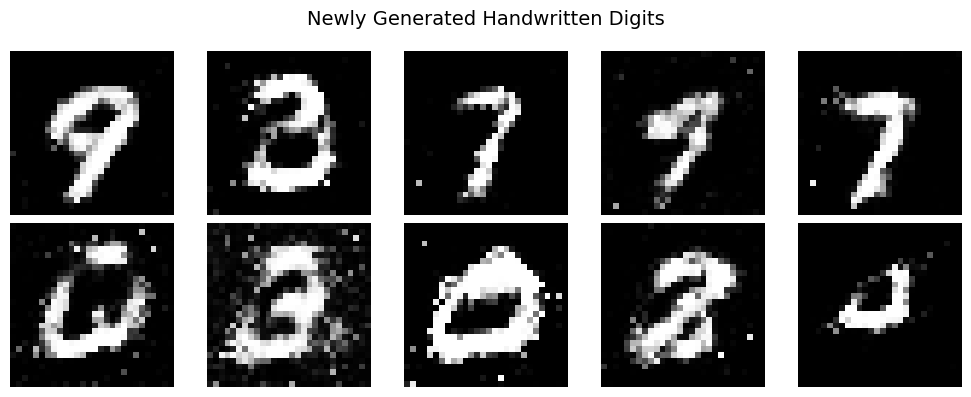

In [ ]:
print('\nGenerating new handwritten digits...')
noise = np.random.normal(0, 1, (10, 100)) # Generate 10 new random noise vectors
images = generator.predict(noise, verbose=0)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Rescale pixel values back from [-1, 1] to [0, 1] for visualization
    plt.imshow(images[i, :, :, 0], cmap='gray')
    plt.axis('off')

plt.suptitle("Newly Generated Handwritten Digits", fontsize=14)
plt.tight_layout()
plt.show()